### Characterization of malignant NK cells (Figure S3)

**Manuscript Context:** This notebook contains the code and workflows used to generate Figure S3 for our study on Extranodal NK/T-cell lymphoma (ENKTCL).

**Objective:**
The goal of this analysis is to characterize the molecular and genetic heterogeneity of malignant NK cells. Specifically, we:
1.  Investigate the relationship between Copy Number Variation (CNV) status and the enrichment of the MHC Class I signature, as well as the expression of key tumor suppressor genes (CDKN1A, CDKN2A).
2.  Assess DNA damage response, indicated by the H2AX enrichment score, specifically within the LMP-1-low malignant NK subpopulation.
3.  Profile the expression of canonical NK cell markers (NCAM1, NKG7, GNLY) across identified subclusters to define phenotypic variation.
4.  Map the expression landscape of immune checkpoint genes (ENTPD1, TIGIT, LAG3, PDCD1, KLRC1, TOX) and infer developmental potency using CytoTRACE2.
5.  Examine the variability of LMP-1 expression across different patients and treatment statuses.

In [ ]:
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib as mpl
import matplotlib.ticker as ticker
import sys
import os
mpl.rcParams['font.family'] = 'Arial'
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["font.size"] = 14
print(sys.version)

In [917]:
figPath = "./figures/figS3"
NKPath = './data/NKTCL_NK.h5ad'
datPath = "./data/NKTCL_concat.h5ad"
os.makedirs(figPath, exist_ok=True)

In [ ]:
adata_NK = sc.read_h5ad(NKPath)
adata_concat = sc.read_h5ad(datPath)

#### **Fig. S3a** Violin plots show the distribution of (a) MHC Class I signature enrichment score
Statistical significance was determined using the two-sided Kruskal-Wallis test. Subsequently, post-hoc pairwise comparisons were performed using the two-sided Wilcoxon rank-sum test. P-values were adjusted for multiple testing using the Benjamini-Hochberg method. 

In [918]:
import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import numpy as np
from scipy import stats
from typing import List, Optional, Tuple, Dict, Any, Union

def plot_violin_stats(
    adata: sc.AnnData, 
    gene: str, 
    groupby: str, 
    ax: Optional[plt.Axes] = None, 
    figsize: Tuple[int, int] = (4, 5),
    jitter: float = 0.4,
    point_size: float = 1,
    order: Optional[List[str]] = None,
    show_p_value: bool = True,
    method: str = 'auto',
    comparisons: Optional[List[Tuple[str, str]]] = None
):
    """
    Plot violin plots with statistical significance markers.
    
    Returns
    -------
    ax : matplotlib.axes.Axes
        The axes object.
    stats_results : List[Dict] or Dict
        Detailed statistical results. 
        If pairwise comparisons: List of dicts containing 'group1', 'group2', 'statistic', 'pvalue', 'mean1', 'mean2', 'direction'.
        If global test: Dict containing 'statistic', 'pvalue', 'method'.
    method_name : str
        Name of the statistical method used.
    """
    
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    if gene not in adata.var_names and gene not in adata.obs.columns:
        raise ValueError(f"Gene '{gene}' not found.")
    if groupby not in adata.obs.columns:
        raise ValueError(f"Group column '{groupby}' not found.")
    
    # Handle categories and order
    all_categories = list(adata.obs[groupby].astype('category').cat.categories)
    if order:
        categories = [c for c in order if c in all_categories]
    else:
        categories = all_categories
        
    if len(categories) < 2:
        raise ValueError("Need at least 2 groups for statistical testing.")
    
    # Extract data efficiently
    values_dict = {}
    for cat in categories:
        mask = adata.obs[groupby] == cat
        idx = np.where(mask)[0]
        if len(idx) > 0:
            if gene in adata.var_names:
                vals = adata[idx, gene].X.toarray().flatten() if hasattr(adata[idx, gene].X, "toarray") else adata[idx, gene].X.flatten()
            else:
                vals = adata.obs.loc[mask, gene].values
            values_dict[cat] = vals
        else:
            values_dict[cat] = np.array([])

    valid_groups = [g for g in categories if len(values_dict[g]) > 0]
    if len(valid_groups) < 2:
        raise ValueError("Less than 2 groups contain data.")
        
    group_data_map = {g: values_dict[g] for g in valid_groups}

    # Determine comparisons to perform
    tests_to_run = []
    global_stat_name = ""
    global_result = {}
    stats_results = [] # To store detailed results

    if comparisons:
        for g1, g2 in comparisons:
            if g1 not in valid_groups or g2 not in valid_groups:
                print(f"Warning: Skipping comparison ({g1}, {g2}) as one group is missing or empty.")
                continue
            tests_to_run.append((g1, g2))
    else:
        if len(valid_groups) == 2:
            tests_to_run.append((valid_groups[0], valid_groups[1]))
        else:
            # Global test for >2 groups
            group_data_list = [group_data_map[g] for g in valid_groups]
            stat_val, p_val = stats.kruskal(*group_data_list)
            global_stat_name = "Kruskal-Wallis"
            global_result = {
                'method': global_stat_name,
                'statistic': stat_val,
                'pvalue': p_val,
                'groups_compared': valid_groups
            }
            # For global test, we return the global_result as the main stats object if no pairwise requested
            if not tests_to_run: 
                stats_results = global_result 

    # Plot Violin
    try:
        sc.pl.violin(
            adata, keys=[gene], groupby=groupby, ax=ax, show=False, 
            order=order, ylabel=gene, xlabel=''
        )
    except Exception:
        df = adata.obs.copy()
        if gene in adata.var_names:
            df[gene] = adata[:, gene].X.toarray().flatten() if hasattr(adata[:, gene].X, "toarray") else adata[:, gene].X.flatten()
        sns.violinplot(x=groupby, y=gene, data=df, ax=ax, order=order, jitter=jitter)
        ax.set_ylabel(gene)
        ax.set_xlabel('')

    # Get X positions
    ax.figure.canvas.draw() 
    x_ticks = list(ax.get_xticks())
    tick_labels = [str(label.get_text()) for label in ax.get_xticklabels()]
    
    pos_map = {}
    if len(x_ticks) == len(tick_labels):
        for pos, label in zip(x_ticks, tick_labels):
            pos_map[label] = pos
    else:
        if len(x_ticks) == len(valid_groups):
            for i, g in enumerate(valid_groups):
                pos_map[g] = x_ticks[i]
        else:
            # Fallback mapping based on order if labels are missing
            # This assumes the plot drew them in the order of 'valid_groups' or 'order'
            # A robust fallback is difficult without labels, but we try:
            current_order = order if order else valid_groups
            for i, g in enumerate(current_order):
                if g in valid_groups and i < len(x_ticks):
                    pos_map[g] = x_ticks[i]

    def get_star(p):
        if p < 0.001: return "***"
        if p < 0.01: return "**"
        if p < 0.05: return "*"
        return "ns"

    y_min, y_max = ax.get_ylim()
    overall_max = max(np.max(v) if len(v)>0 else -np.inf for v in group_data_map.values())
    range_y = y_max - y_min
    if range_y == 0: range_y = 1
    
    current_height = overall_max
    
    # 1. Draw Pairwise Comparisons & Collect Stats
    if tests_to_run:
        stats_results = [] # Reset to list for pairwise
        for g1, g2 in tests_to_run:
            d1, d2 = group_data_map[g1], group_data_map[g2]
            stat_val, p_val = stats.mannwhitneyu(d1, d2, alternative='two-sided')
            
            # Calculate descriptive stats
            m1, m2 = np.mean(d1), np.mean(d2)
            med1, med2 = np.median(d1), np.median(d2)
            
            # Determine direction
            if m1 > m2: direction = f"{g1} > {g2}"
            elif m2 > m1: direction = f"{g2} > {g1}"
            else: direction = "Equal"
            
            res_dict = {
                'group1': g1, 'group2': g2,
                'statistic': stat_val, # U value
                'pvalue': p_val,
                'mean1': m1, 'mean2': m2,
                'median1': med1, 'median2': med2,
                'direction': direction,
                'method': 'Mann-Whitney U'
            }
            stats_results.append(res_dict)
            
            # Plotting logic
            if p_val < 0.05 and show_p_value:
                if g1 not in pos_map or g2 not in pos_map:
                    continue
                    
                x1, x2 = pos_map[g1], pos_map[g2]
                offset = range_y * 0.05
                bar_height = offset * 0.5
                y_line = current_height + offset
                
                ax.plot([x1, x2], [y_line, y_line], color='black', linewidth=1.2)
                ax.plot([x1, x1], [y_line, y_line - bar_height], color='black', linewidth=1.2)
                ax.plot([x2, x2], [y_line, y_line - bar_height], color='black', linewidth=1.2)
                
                p_str = f"p={p_val:.2e}" if p_val < 0.0001 else f"p={p_val:.3f}"
                star = get_star(p_val)
                # Optionally add direction to the plot text if space permits, otherwise just star/p
                ax.text((x1 + x2) / 2, y_line + bar_height*0.2, f"{star}\n({p_str})", 
                        ha='center', va='bottom', fontsize=10, fontweight='bold')
                
                current_height = y_line + bar_height * 1.2

    # 2. Draw Global Significance
    if not comparisons and len(valid_groups) > 2 and global_stat_name:
        if global_result['pvalue'] < 0.05 and show_p_value:
            x_start, x_end = x_ticks[0], x_ticks[-1]
            offset = range_y * 0.05
            bar_height = offset * 0.5
            y_line = current_height + offset
            
            ax.plot([x_start, x_end], [y_line, y_line], color='black', linewidth=1.2)
            ax.plot([x_start, x_start], [y_line, y_line - bar_height], color='black', linewidth=1.2)
            ax.plot([x_end, x_end], [y_line, y_line - bar_height], color='black', linewidth=1.2)
            
            p_str = f"p={global_result['pvalue']:.2e}" if global_result['pvalue'] < 0.0001 else f"p={global_result['pvalue']:.3f}"
            star = get_star(global_result['pvalue'])
            ax.text((x_start + x_end) / 2, y_line + bar_height*0.2, f"{star}\n({p_str})\n(Global)", 
                    ha='center', va='bottom', fontsize=10, fontweight='bold')
            
            current_height = y_line + bar_height * 1.2

    if current_height > overall_max:
        ax.set_ylim(y_min, current_height + range_y * 0.05)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_axisbelow(True)
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    
    method_name = stats_results[0]['method'] if isinstance(stats_results, list) and stats_results else (global_result.get('method', 'Unknown'))
    
    return ax, stats_results, method_name

In [ ]:
def print_stat(stat, method):
    print(f"--- Statistical Analysis ({method}) ---")

    if isinstance(stat, list):
        #  pairwise comparisons
        for res in stat:
            print(f"Comparison: {res['group1']} vs {res['group2']}")
            print(f"  Direction: {res['direction']}")
            print(f"  Mean ({res['group1']}): {res['mean1']:.4f}")
            print(f"  Mean ({res['group2']}): {res['mean2']:.4f}")
            print(f"  Statistic (U): {res['statistic']:.2f}")
            print(f"  P-value: {res['pvalue']:.4e}")
            print("-" * 30)
    else:
        # Global test
        print(f"Global Test: {stat['method']}")
        print(f"  Statistic (H): {stat['statistic']:.2f}")
        print(f"  P-value: {stat['pvalue']:.4e}")

/tmp/ipykernel_3335451/2505453437.py:17: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



--- Statistical Analysis (Mann-Whitney U) ---
Comparison: Malig NK (non-classical) vs Malig NK (classical)
  Direction: Malig NK (classical) > Malig NK (non-classical)
  Mean (Malig NK (non-classical)): 0.2402
  Mean (Malig NK (classical)): 0.3249
  Statistic (U): 23908899.00
  P-value: 0.0000e+00
------------------------------
Comparison: Malig NK (non-classical) vs Normal NK
  Direction: Normal NK > Malig NK (non-classical)
  Mean (Malig NK (non-classical)): 0.2402
  Mean (Normal NK): 0.3395
  Statistic (U): 3421312.00
  P-value: 1.2358e-309
------------------------------


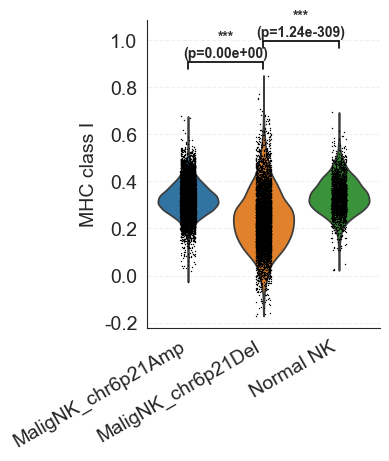

In [925]:
# calculating MHC class I and MHC class II
mhc_class_i = ['HLA-A', 'HLA-B', 'HLA-C', 'B2M', 'TAP1', 'TAP2', 'PSMB8', 'PSMB9', 'HLA-G', 'HLA-E',]
mhc_class_ii = ['HLA-DRA', 'HLA-DRB1', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DQA1', 
                'HLA-DQB1' ]
sc.tl.score_genes(adata_NK, gene_list=mhc_class_i, score_name='MHC class I')
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
comparisons = [('Malig NK (non-classical)', 'Malig NK (classical)'), ('Malig NK (non-classical)', 'Normal NK')]
ax, stat, stat_name = plot_violin_stats(
    adata=adata_NK[~adata_NK.obs['anno-cnv'].isin(['reference'])],
    gene='MHC class I',
    groupby='anno-cnv',
    ax=ax,
    comparisons=comparisons, 
    order=['Malig NK (classical)', 'Malig NK (non-classical)', 'Normal NK']
)
ax.set_xlabel('')
ax.set_xticklabels(['MaligNK_chr6p21Amp', 'MaligNK_chr6p21Del', 'Normal NK'], rotation=30, ha='right')
fig.savefig(f"{figPath}/FigS3a.png", dpi=150, bbox_inches='tight')
print_stat(stat, stat_name)

#### **Fig. S3b** Violin plots show the distribution of CDKN1A expression

--- Statistical Analysis (Mann-Whitney U) ---
Comparison: Malig NK (non-classical) vs Malig NK (classical)
  Direction: Malig NK (classical) > Malig NK (non-classical)
  Mean (Malig NK (non-classical)): 0.0901
  Mean (Malig NK (classical)): 0.2463
  Statistic (U): 26701913.50
  P-value: 0.0000e+00
------------------------------
Comparison: Malig NK (non-classical) vs Normal NK
  Direction: Normal NK > Malig NK (non-classical)
  Mean (Malig NK (non-classical)): 0.0901
  Mean (Normal NK): 0.1123
  Statistic (U): 6527062.00
  P-value: 1.9251e-24
------------------------------


/tmp/ipykernel_3335451/3598204668.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



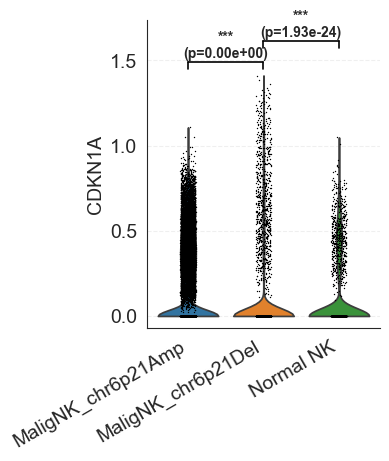

In [926]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
comparisons = [('Malig NK (non-classical)', 'Malig NK (classical)'), ('Malig NK (non-classical)', 'Normal NK')]
ax, stat, method = plot_violin_stats(
    adata=adata_NK[~adata_NK.obs['anno-cnv'].isin(['reference'])],
    gene='CDKN1A',
    groupby='anno-cnv',
    ax=ax,
    comparisons=comparisons,
    order=['Malig NK (classical)', 'Malig NK (non-classical)', 'Normal NK']
)
ax.set_xlabel('')
ax.set_xticklabels(['MaligNK_chr6p21Amp', 'MaligNK_chr6p21Del', 'Normal NK'], rotation=30, ha='right')
fig.savefig(f"{figPath}/FigS3b.png", dpi=150, bbox_inches='tight')
print_stat(stat, stat_name)

#### **Fig. S3c** Violin plots show the distribution of CDKN2A expression

/tmp/ipykernel_3335451/626604799.py:12: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



--- Statistical Analysis (Mann-Whitney U) ---
Comparison: Malig NK (non-classical) vs Malig NK (classical)
  Direction: Malig NK (classical) > Malig NK (non-classical)
  Mean (Malig NK (non-classical)): 0.0754
  Mean (Malig NK (classical)): 0.1958
  Statistic (U): 25131704.00
  P-value: 0.0000e+00
------------------------------
Comparison: Malig NK (non-classical) vs Normal NK
  Direction: Malig NK (non-classical) > Normal NK
  Mean (Malig NK (non-classical)): 0.0754
  Mean (Normal NK): 0.0234
  Statistic (U): 7702724.50
  P-value: 6.4174e-21
------------------------------


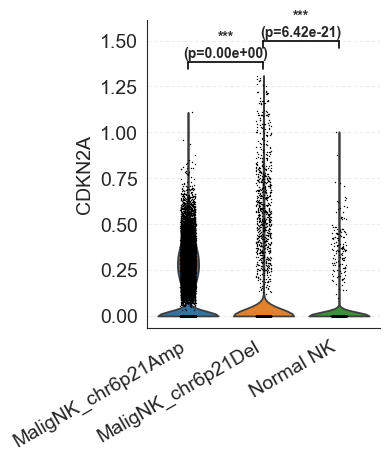

In [927]:
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
comparisons = [('Malig NK (non-classical)', 'Malig NK (classical)'), ('Malig NK (non-classical)', 'Normal NK')]
ax, stat, method = plot_violin_stats(
    adata=adata_NK[~adata_NK.obs['anno-cnv'].isin(['reference'])],
    gene='CDKN2A',
    groupby='anno-cnv',
    ax=ax,
    comparisons=comparisons,
    order=['Malig NK (classical)', 'Malig NK (non-classical)', 'Normal NK']
)
ax.set_xlabel('')
ax.set_xticklabels(['MaligNK_chr6p21Amp', 'MaligNK_chr6p21Del', 'Normal NK'], rotation=30, ha='right')
fig.savefig(f"{figPath}/FigS3c.png", dpi=150, bbox_inches='tight')
print_stat(stat, stat_name)

#### **Fig. S3d** Violin plots show the distribution of H2AX enrichment score across LMP-1-low MaligNK (NK01, NK08, and NK09) and other populations.

Statistical significance was determined using the two-sided Wilcoxon test. In all panels, center lines indicate medians, box limits represent interquartile ranges (IQR), and whiskers extend to 1.5× IQR. Individual cells are shown as jittered dots. Significance levels: ns, not significant; P < 0.05; P < 0.01; P < 0.001. Exact P-values and mean values are provided in the figures. 

/home/rzh/miniconda3/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning:

Trying to modify attribute `.obs` of view, initializing view as actual.



--- Statistical Analysis (Mann-Whitney U) ---
Comparison: LMP-1-low MaligNK vs Others
  Direction: LMP-1-low MaligNK > Others
  Mean (LMP-1-low MaligNK): 0.2126
  Mean (Others): 0.1368
  Statistic (U): 75722906.00
  P-value: 2.0237e-52
------------------------------


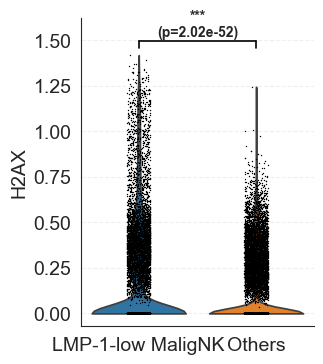

In [929]:
# draw H2AX violin plot
def anno(adata:ad.AnnData, annoDict:dict, obsKey='cnv_status', obsVal='cnv_leiden', default="Unknown"):
  if default is not None:
    adata.obs[obsKey] = default
  for key in annoDict.keys():
    adata.obs.loc[adata.obs[obsVal].isin(annoDict[key]), obsKey] = key
  return adata
annot = {
  "LMP-1-low MaligNK": ['NK01: Malig_MKI67','NK08: Malig_IL2RA', 'NK09: Malig_H2AC11'],
  "Others":['NK02: Malig_CD56', 'NK03: Malig_CD16',
       'NK04: Malig_CD200R1', 'NK05: Malig_FGFBP2', 'NK06: Norm_FGFBP2',
       'NK07: Norm_KIT',]
}
adata_NK = anno(adata_NK, annot, 'H2AX-status', 'CellStateLabels')
fig, ax = plt.subplots(1, 1, figsize=(3, 4))

ax, stat, method = plot_violin_stats(
    adata=adata_NK[~adata_NK.obs['anno-cnv'].isin(['reference'])],
    gene='H2AX',
    groupby='H2AX-status',
    ax=ax,
    order=['LMP-1-low MaligNK', 'Others'], 
    jitter=0.4
)
ax.set_xlabel('')
fig.savefig(f"{figPath}/FigS3d.png", dpi=400, bbox_inches='tight')
print_stat(stat, stat_name)

#### **Fig. S3e** Violin plots showing the expression levels of NCAM1 across NK cell subclusters.

/tmp/ipykernel_3335451/3889473926.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



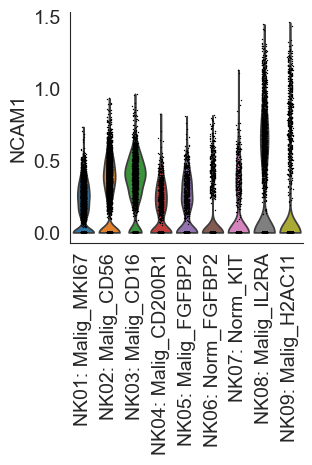

In [933]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sc.pl.violin(adata_NK, keys=['NCAM1'], groupby='CellStateLabels', ax=ax,show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_NK.obs['CellStateLabels'].cat.categories, rotation=90)
fig.savefig(f"{figPath}/FigS3e.png", dpi=150, bbox_inches='tight')

#### **Fig. S3f** Violin plots showing the expression levels of NKG7 across NK cell subclusters.

/tmp/ipykernel_3335451/2983207471.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



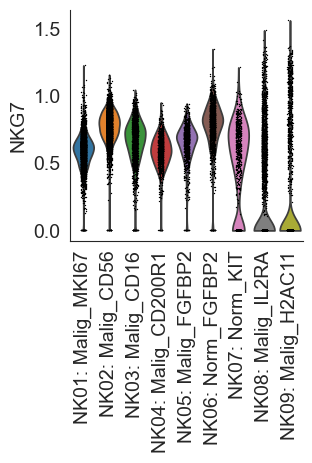

In [932]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sc.pl.violin(adata_NK, keys=['NKG7'], groupby='CellStateLabels', ax=ax,show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_NK.obs['CellStateLabels'].cat.categories, rotation=90)
fig.savefig(f"{figPath}/FigS3f.png", dpi=150, bbox_inches='tight')

#### **Fig. S3g** Violin plots showing the expression levels of GNLY across NK cell subclusters.

/tmp/ipykernel_3335451/3210704531.py:6: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



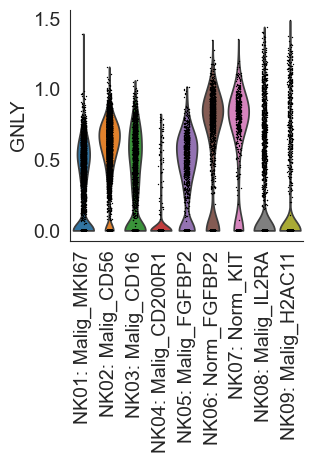

In [931]:
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
sc.pl.violin(adata_NK, keys=['GNLY'], groupby='CellStateLabels', ax=ax,show=False)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel("")
ax.set_xticklabels(adata_NK.obs['CellStateLabels'].cat.categories, rotation=90)
fig.savefig(f"{figPath}/FigS3g.png", dpi=150, bbox_inches='tight')

#### **Fig. S3h** Expression of immune checkpoint genes in NK cells. 
UMAP plots illustrating the expression of immune checkpoint genes (ENTPD1, TIGIT, LAG3, PDCD1, KLRC1, and TOX), with color gra-dients indicating expression intensity from purple (low) to yellow (high).

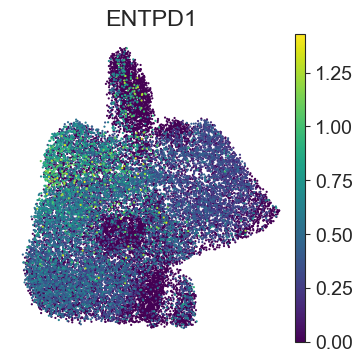

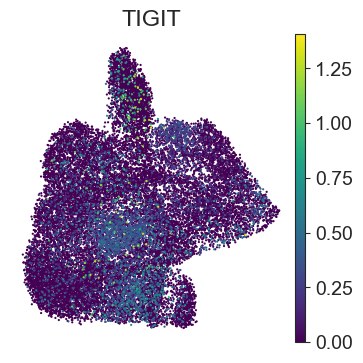

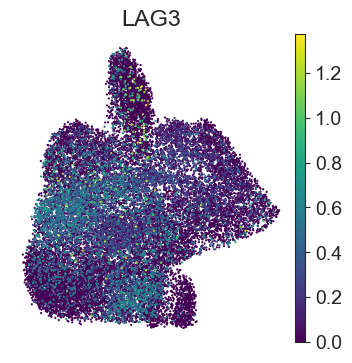

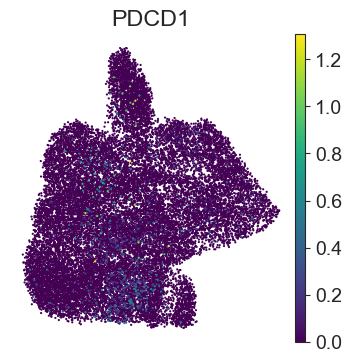

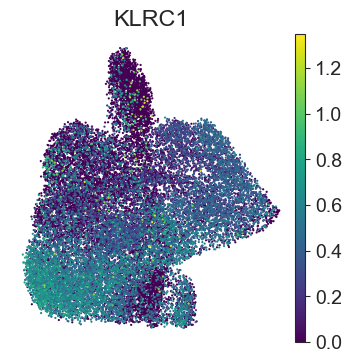

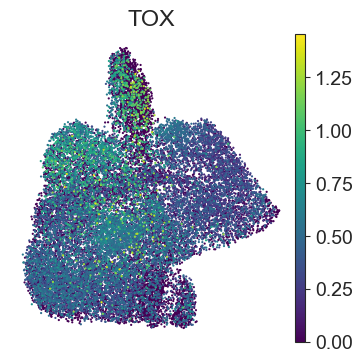

In [935]:
for gene in ['ENTPD1', 'TIGIT', 'LAG3', 'PDCD1', 'KLRC1', 'TOX']:
  fig, ax = plt.subplots(1, 1, figsize=(4, 4))
  sc.pl.umap(adata_NK, color=gene,size=10, ax=ax, show=False, cmap='viridis')
  ax.spines['right'].set_visible(False)
  ax.spines['top'].set_visible(False)
  ax.spines['left'].set_visible(False)
  ax.spines['bottom'].set_visible(False)
  ax.set_xlabel("")
  ax.set_ylabel("")
  fig.savefig(f"{figPath}/FigS3h-{gene}.png", dpi=150, bbox_inches='tight')

#### **Fig. S3i** Developmental potential of NK cells. 
UMAP visualization of NK-cell developmental potency in-ferred by CytoTRACE2, with blue indicating low potential and green indicating high potential.

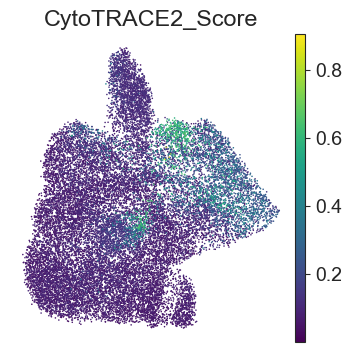

In [937]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
sc.pl.umap(adata_NK, color=['CytoTRACE2_Score'], show=False, ax=ax, cmap='viridis')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel("")
ax.set_ylabel("")
fig.savefig(f'{figPath}/FigS3i.png', dpi=150, bbox_inches='tight')

#### **Fig. S3j** Violin plots show gene expression of LMP-1 per patient

/tmp/ipykernel_3335451/2332179053.py:3: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



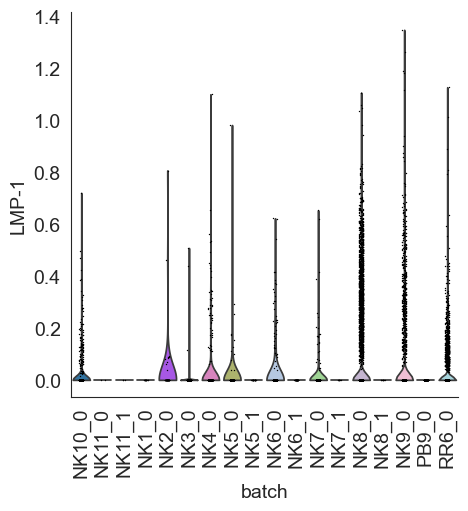

In [944]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.violin(adata_concat[adata_concat.obs['anno-pca'] == 'NK cells'], keys=['LMP-1'], groupby='batch', ax=ax, show=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
fig.savefig(f"{figPath}/FigS3j.png", dpi=150, bbox_inches='tight')

#### **Fig. S3k** Violin plots show gene expression of LMP-1 per treatment status

/tmp/ipykernel_3335451/2799364646.py:3: UserWarning:

set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.



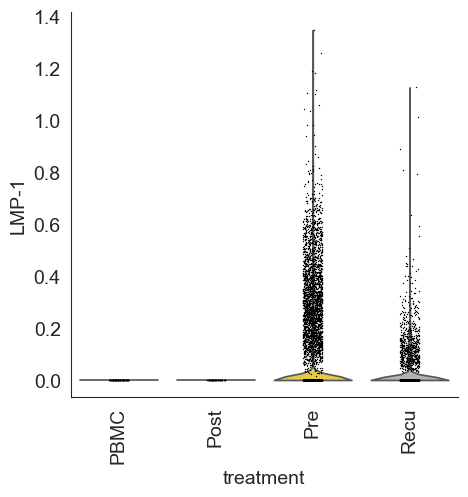

In [945]:
fig, ax = plt.subplots(figsize=(5, 5))
sc.pl.violin(adata_concat[adata_concat.obs['anno-pca'] == 'NK cells'], keys=['LMP-1'], groupby='treatment', ax=ax, show=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
fig.savefig(f"{figPath}/FigS3k.png", dpi=150, bbox_inches='tight')